## Preparación del problema de clasificación

Este notebook inicia la fase de modelado del proyecto. Partiendo del dataset previamente procesado, se define el conjunto de variables predictoras y las variables objetivo, se establece una estrategia de validación temporal y se seleccionan las métricas que se utilizarán para comparar los modelos.

Antes de realizar el entrenamiento se presenta una revisión resumida de la distribución de los códigos de calidad. El análisis detallado de estas variables ya fue realizado durante el EDA, por lo que en esta fase únicamente se recupera la información necesaria para definir correctamente el problema de clasificación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

DATA_PATH = "../data/processed/dataset_solar_2023_2024_v3.parquet"

df = pd.read_parquet(DATA_PATH)

print(df.shape)
df.head()

(1052640, 27)


,ano,mes_sin,mes_cos,dia,hora_sin,hora_cos,minuto,fecha,ghi,dni,...,periodo_solar,temperatura,velocidad_viento,humedad_relativa,direccion_viento_sin,direccion_viento_cos,var_meteo_imp,codigo_ghi,codigo_dni,codigo_dhi
0,2023,0.0,1.0,1,0.0,1.0,0,2023-01-01 00:00:00,0.0,0.0,...,noche,10.0,1.050,77.0,0.884988,-0.465615,False,0,0,0
1,2023,0.0,1.0,1,0.0,1.0,1,2023-01-01 00:01:00,0.0,0.0,...,noche,10.0,1.333,77.0,-0.748956,0.662620,False,0,0,0
2,2023,0.0,1.0,1,0.0,1.0,2,2023-01-01 00:02:00,0.0,0.0,...,noche,10.0,1.100,77.0,-0.972031,-0.234854,False,0,0,0
3,2023,0.0,1.0,1,0.0,1.0,3,2023-01-01 00:03:00,0.0,0.0,...,noche,10.0,1.333,77.0,-0.937179,0.348850,False,0,0,0
4,2023,0.0,1.0,1,0.0,1.0,4,2023-01-01 00:04:00,0.0,0.0,...,noche,10.0,1.058,77.0,-0.443587,0.896231,False,0,0,0


In [2]:
TARGETS = [
    "codigo_ghi",
    "codigo_dni",
    "codigo_dhi"
]

In [3]:
for target in TARGETS:
    distribution = (
        df[target]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame("n")
    )

    distribution["percentage"] = (
        distribution["n"] / len(df) * 100
    )

    print(f"\n{target}")
    display(distribution)


codigo_ghi


,n,percentage
codigo_ghi,,
0,899970,85.496466
1,152670,14.503534



codigo_dni


,n,percentage
codigo_dni,,
0,943668,89.647743
1,107047,10.169384
2,1925,0.182874



codigo_dhi


,n,percentage
codigo_dhi,,
0,860006,81.699916
1,192246,18.263224
2,388,0.036860


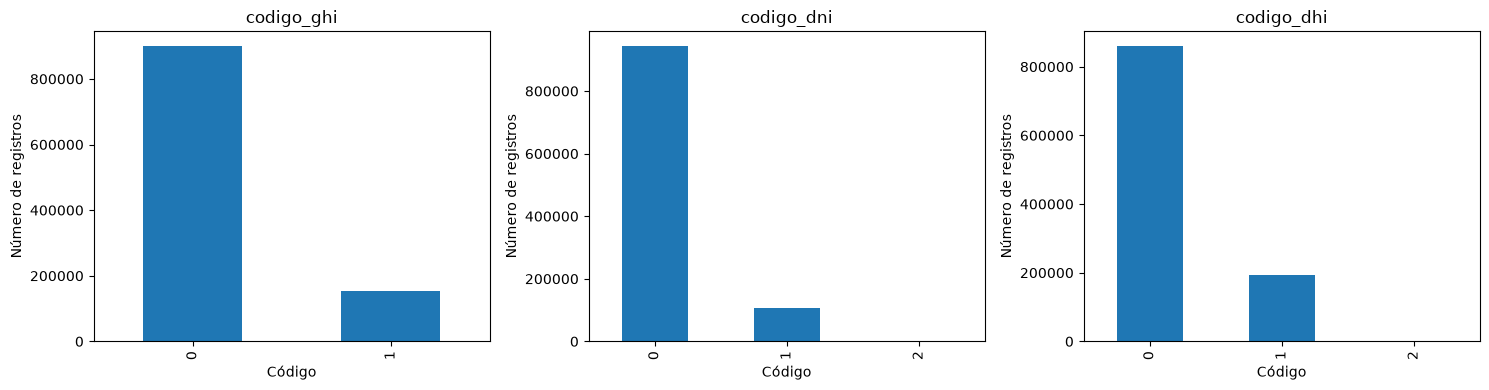

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, target in zip(axes, TARGETS):
    df[target].value_counts().sort_index().plot(
        kind="bar",
        ax=ax
    )
    ax.set_title(target)
    ax.set_xlabel("Código")
    ax.set_ylabel("Número de registros")

plt.tight_layout()
plt.show()

### Distribución de las variables objetivo

Como ya se observó durante el análisis exploratorio, las tres variables objetivo presentan un claro desbalance entre clases. `codigo_ghi` constituye un problema binario, mientras que `codigo_dni` y `codigo_dhi` contienen una tercera clase muy minoritaria.

La clase 0 es mayoritaria en los tres casos, representando entre el 81,7 % y el 89,6 % de las observaciones. La clase 1 tiene una presencia considerablemente menor, mientras que la clase 2 representa únicamente el 0,18 % de los registros en DNI y el 0,04 % en DHI.

Esta distribución confirma la necesidad de utilizar métricas que tengan en cuenta el rendimiento sobre las clases minoritarias y no basar la comparación de modelos únicamente en la exactitud global.

In [5]:
for target in TARGETS:
    distribution_year = pd.crosstab(
        df["ano"],
        df[target],
        normalize="index"
    ) * 100

    print(f"\nDistribución por año - {target}")
    display(distribution_year.round(2))


Distribución por año - codigo_ghi


codigo_ghi,0,1
ano,,
2023,88.08,11.92
2024,82.92,17.08



Distribución por año - codigo_dni


codigo_dni,0,1,2
ano,,,
2023,95.84,3.95,0.21
2024,83.47,16.37,0.16



Distribución por año - codigo_dhi


codigo_dhi,0,1,2
ano,,,
2023,89.03,10.93,0.03
2024,74.39,25.57,0.04


### Comparación de la distribución entre años

La distribución de los códigos presenta diferencias apreciables entre 2023 y 2024. En particular, 2024 contiene una mayor proporción de observaciones correspondientes a la clase 1 en los tres objetivos: 17,08 % frente a 11,92 % para GHI, 16,37 % frente a 3,95 % para DNI y 25,57 % frente a 10,93 % para DHI.

En las clases más infrecuentes, la representación es similar entre ambos años: 2023 presenta una proporción ligeramente superior de la clase 2 de DNI, mientras que 2024 presenta una proporción ligeramente superior de la clase 2 de DHI.

Considerando conjuntamente los tres problemas de clasificación, se selecciona **2024 como conjunto de entrenamiento**, ya que ofrece una representación más amplia de las clases minoritarias, especialmente de la clase 1. Los datos de **2023 se reservan como conjunto de prueba independiente** para evaluar la capacidad de generalización del modelo entre años.

In [6]:
df.columns.tolist()

['ano',
 'mes_sin',
 'mes_cos',
 'dia',
 'hora_sin',
 'hora_cos',
 'minuto',
 'fecha',
 'ghi',
 'dni',
 'dhi',
 'ghi_estimado',
 'irr_null',
 'error_balance',
 'error_balance_abs',
 'error_balance_rel',
 'elevacion_solar',
 'periodo_solar',
 'temperatura',
 'velocidad_viento',
 'humedad_relativa',
 'direccion_viento_sin',
 'direccion_viento_cos',
 'var_meteo_imp',
 'codigo_ghi',
 'codigo_dni',
 'codigo_dhi']

In [7]:
TARGET_COLUMNS = [
    "codigo_ghi",
    "codigo_dni",
    "codigo_dhi"
]

IDENTIFIER_COLUMNS = [
    "fecha"
]

CANDIDATE_FEATURES = [x for x in df.columns.tolist() if x not in TARGET_COLUMNS + IDENTIFIER_COLUMNS]
print(f"Número de candidatos a features de los modelos: {len(CANDIDATE_FEATURES)}")

Número de candidatos a features de los modelos: 23


In [8]:
feature_review = pd.DataFrame({
    "feature": CANDIDATE_FEATURES,
    "dtype": [df[col].dtype for col in CANDIDATE_FEATURES],
    "missing_values": [df[col].isna().sum() for col in CANDIDATE_FEATURES],
    "missing_percentage": [
        round(df[col].isna().mean() * 100, 2)
        for col in CANDIDATE_FEATURES
    ]
})

feature_review

,feature,dtype,missing_values,missing_percentage
0,ano,int64,0,0.00
1,mes_sin,float64,0,0.00
2,mes_cos,float64,0,0.00
3,dia,int64,0,0.00
4,hora_sin,float64,0,0.00
5,hora_cos,float64,0,0.00
6,minuto,int64,0,0.00
7,ghi,float64,11868,1.13
8,dni,float64,11868,1.13
9,dhi,float64,11868,1.13


### Disponibilidad de las variables predictoras

La revisión de las variables candidatas muestra que la mayor parte de las características temporales y solares se encuentran completas. Las variables de irradiancia y las magnitudes derivadas de ellas presentan aproximadamente un 1,13 % de valores ausentes, mientras que las variables meteorológicas concentran alrededor de un 9 % de valores nulos.

Estos valores se conservarán en esta fase en lugar de aplicar nuevas imputaciones. Parte de las ausencias no pudo ser reconstruida de forma suficientemente fiable durante el preprocesamiento previo y su eliminación supondría descartar información potencialmente relevante.

Por este motivo, se priorizarán inicialmente algoritmos capaces de gestionar valores ausentes de forma nativa, evitando introducir una nueva etapa de imputación exclusivamente para adaptar los datos al modelo.

## Estrategia de entrenamiento y evaluación

Se utiliza una estrategia de validación interanual, manteniendo completamente separados los registros correspondientes a cada año. Los datos de 2024 se emplean para el desarrollo de los modelos, mientras que los registros de 2023 permanecen reservados para su evaluación independiente.

La elección de 2024 como conjunto de entrenamiento responde a su mayor representación de las clases minoritarias en los tres objetivos de clasificación. Al evitar la mezcla de observaciones de ambos años se reduce, además, el riesgo de que registros temporalmente muy próximos aparezcan simultáneamente en entrenamiento y prueba, aspecto especialmente relevante en datos con resolución minuto a minuto.

In [9]:
train_df = df[df["ano"] == 2024].copy()
test_df = df[df["ano"] == 2023].copy()

print(f"Train 2024: {train_df.shape}")
print(f"Test 2023: {test_df.shape}")

Train 2024: (527040, 27)
Test 2023: (525600, 27)


La división interanual hace que la variable `ano` sea constante dentro de cada conjunto de datos y, por tanto, no aporte información útil al entrenamiento. Por este motivo se excluye del conjunto de variables predictoras.

Además, se adaptan a formato numérico las variables binarias utilizadas por los modelos. `periodo_solar`, originalmente representada mediante las categorías `dia` y `noche`, se codifica como una variable binaria, al igual que los indicadores booleanos `var_meteo_imp` e `irr_null`. Esta transformación modifica únicamente su representación y no implica ninguna alteración de la información contenida en las variables.

In [10]:
EXCLUDED_FEATURES = [
    "ano"
]

FEATURES = [
    col for col in CANDIDATE_FEATURES
    if col not in EXCLUDED_FEATURES
]

In [50]:
for dataset in [df, train_df, test_df]:

    dataset["periodo_solar"] = dataset["periodo_solar"].replace({
        "noche": 0,
        "dia": 1
    })

    dataset["var_meteo_imp"] = dataset["var_meteo_imp"].astype(int)

    dataset["irr_null"] = dataset["irr_null"].astype(int)

## Métricas de evaluación

Dado el importante desbalance existente entre los códigos de calidad, la evaluación de los modelos se centrará en un conjunto reducido de métricas que permita comparar claramente su rendimiento sin que las clases mayoritarias oculten el comportamiento sobre las menos frecuentes.

La **Macro F1** se utilizará como métrica principal y como criterio para seleccionar el mejor modelo. Esta métrica calcula el F1 de cada clase de forma independiente y posteriormente obtiene su media sin ponderar por el número de observaciones, otorgando así la misma importancia a las clases mayoritarias y minoritarias.

Como métricas complementarias se utilizarán la **Balanced Accuracy**, que permite comprobar la capacidad del modelo para identificar correctamente las distintas clases independientemente de su frecuencia, y la **Weighted F1**, que proporciona una visión del rendimiento global ponderando cada clase según su representación en el conjunto de datos.

Finalmente, se analizará la **matriz de confusión** de cada modelo para estudiar qué tipos de errores se producen y, especialmente, cómo se comporta el clasificador sobre las clases minoritarias.

In [12]:
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def evaluate_classifier(y_true, y_pred):
    return {
        "f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }

## Modelos iniciales de referencia

Antes de comparar diferentes algoritmos se establecen dos niveles iniciales de referencia. En primer lugar, se utiliza un `DummyClassifier` que predice siempre la clase mayoritaria y permite determinar el rendimiento mínimo que cualquier modelo útil debería superar.

Posteriormente se entrena un `HistGradientBoostingClassifier` como primer modelo supervisado. Este algoritmo permite trabajar directamente con los valores ausentes que permanecen en el dataset y proporciona una primera referencia predictiva sin realizar todavía optimización de hiperparámetros.

In [13]:
from sklearn.dummy import DummyClassifier

dummy_results = []
dummy_predictions = {}

X_train = train_df[FEATURES]
X_test = test_df[FEATURES]

for target in TARGETS:

    y_train = train_df[target]
    y_test = test_df[target]

    model = DummyClassifier(
        strategy="most_frequent"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    metrics = evaluate_classifier(
        y_test,
        y_pred
    )

    metrics.update({
        "model": "DummyClassifier",
        "target": target
    })

    dummy_results.append(metrics)
    dummy_predictions[target] = y_pred

dummy_results = pd.DataFrame(dummy_results)

dummy_results

,f1_macro,balanced_accuracy,f1_weighted,model,target
0,0.468299,0.500000,0.824916,DummyClassifier,codigo_ghi
1,0.326260,0.333333,0.938106,DummyClassifier,codigo_dni
2,0.313993,0.333333,0.838667,DummyClassifier,codigo_dhi


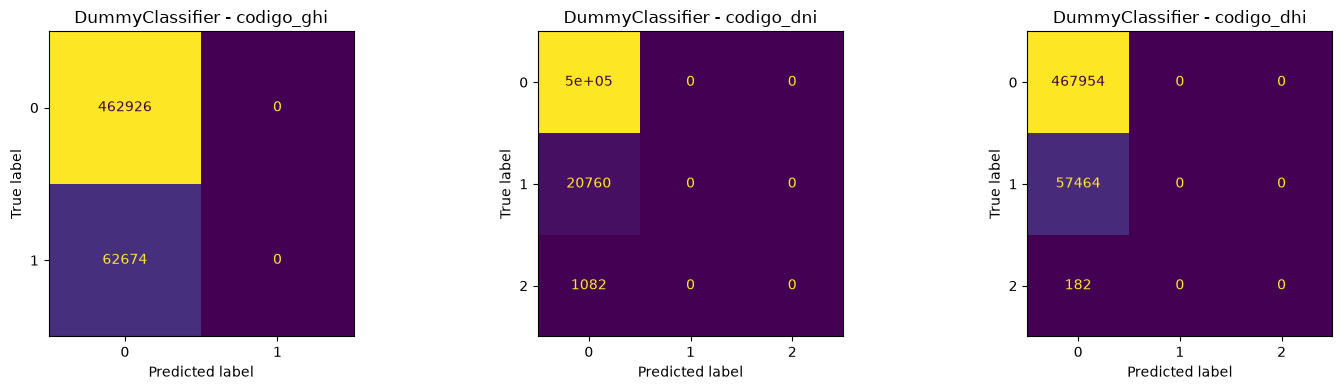

In [14]:
fig, axes = plt.subplots(
    1,
    len(TARGETS),
    figsize=(15, 4)
)

for ax, target in zip(axes, TARGETS):

    y_test = test_df[target]
    y_pred = dummy_predictions[target]

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        ax=ax,
        colorbar=False
    )

    ax.set_title(
        f"DummyClassifier - {target}"
    )

plt.tight_layout()
plt.show()

### Resultados del modelo de referencia

El `DummyClassifier` establece el nivel mínimo de rendimiento que deben superar los modelos predictivos posteriores. Al predecir sistemáticamente la clase mayoritaria, obtiene valores de Macro F1 de 0,468 para GHI, 0,326 para DNI y 0,314 para DHI.

La Balanced Accuracy toma el valor esperado de 0,50 en el problema binario de GHI y aproximadamente 0,33 en los problemas de tres clases de DNI y DHI, confirmando que el modelo no posee capacidad real para distinguir entre las diferentes categorías.

En contraste, los valores elevados de Weighted F1, especialmente en DNI, muestran el efecto del fuerte desbalance existente: un modelo sin capacidad predictiva puede obtener un rendimiento global aparentemente elevado simplemente favoreciendo la clase mayoritaria. Este resultado refuerza la elección de Macro F1 como principal criterio de comparación.

In [15]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_results = []
hgb_models = {}
hgb_predictions = {}

X_train = train_df[FEATURES]
X_test = test_df[FEATURES]

for target in TARGETS:

    y_train = train_df[target]
    y_test = test_df[target]

    model = HistGradientBoostingClassifier(
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(X_test)

    metrics = evaluate_classifier(
        y_test,
        y_pred
    )

    metrics.update({
        "model": "HistGradientBoostingClassifier",
        "target": target
    })

    hgb_results.append(metrics)

    hgb_models[target] = model
    hgb_predictions[target] = y_pred

hgb_results = pd.DataFrame(hgb_results)

hgb_results

,f1_macro,balanced_accuracy,f1_weighted,model,target
0,0.625920,0.612946,0.851454,HistGradientBoostingClassifier,codigo_ghi
1,0.486994,0.616805,0.932485,HistGradientBoostingClassifier,codigo_dni
2,0.498600,0.572575,0.882477,HistGradientBoostingClassifier,codigo_dhi


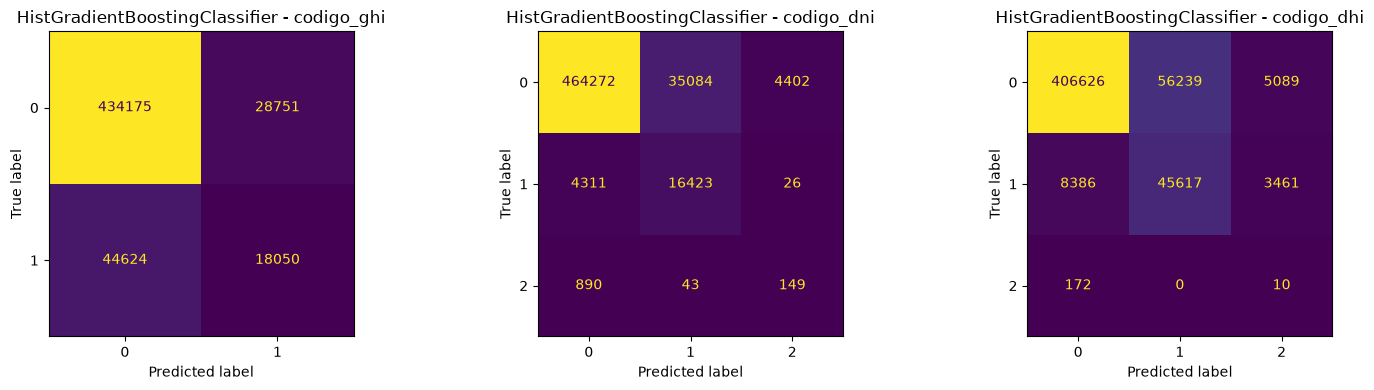

In [16]:
fig, axes = plt.subplots(
    1,
    len(TARGETS),
    figsize=(15, 4)
)

for ax, target in zip(axes, TARGETS):

    y_test = test_df[target]
    y_pred = hgb_predictions[target]

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        ax=ax,
        colorbar=False
    )

    ax.set_title(
        f"HistGradientBoostingClassifier - {target}"
    )

plt.tight_layout()
plt.show()

### Resultados del modelo base supervisado

El `HistGradientBoostingClassifier` mejora claramente el rendimiento del modelo de referencia en los tres problemas de clasificación. La Macro F1 alcanza 0,626 para GHI, 0,487 para DNI y 0,499 para DHI, frente a 0,468, 0,326 y 0,314 respectivamente con el `DummyClassifier`.

La mejora se observa también en la Balanced Accuracy, que aumenta hasta 0,613 para GHI, 0,617 para DNI y 0,573 para DHI. Por tanto, el modelo comienza a identificar información relevante para diferenciar las distintas clases y no se limita a favorecer la categoría mayoritaria.

Sin embargo, la diferencia existente entre Macro F1 y Weighted F1 sigue siendo considerable, especialmente en DNI y DHI. Esto indica que el rendimiento continúa siendo sensiblemente mejor sobre las clases más frecuentes que sobre las minoritarias. Las matrices de confusión permiten analizar posteriormente en qué clases concretas se concentran estos errores.

Estos resultados se utilizarán como primera referencia supervisada para evaluar si los modelos posteriores aportan una mejora real.

In [17]:
model_results = pd.concat(
    [
        dummy_results,
        hgb_results
    ],
    ignore_index=True
)

model_results = model_results[
    [
        "model",
        "target",
        "f1_macro",
        "balanced_accuracy",
        "f1_weighted"
    ]
].sort_values(
    ["target", "f1_macro"],
    ascending=[True, False]
)

In [18]:
comparison = model_results.pivot(
    index="model",
    columns="target",
    values="f1_macro"
)

comparison

target,codigo_dhi,codigo_dni,codigo_ghi
model,,,
DummyClassifier,0.313993,0.326260,0.468299
HistGradientBoostingClassifier,0.498600,0.486994,0.625920


### Comparación de los modelos iniciales

La comparación mediante Macro F1 confirma que el `HistGradientBoostingClassifier` supera al modelo de referencia en los tres objetivos. La mejora absoluta es de aproximadamente 0,158 puntos en GHI, 0,161 en DNI y 0,185 en DHI.

La mayor Macro F1 se obtiene inicialmente para GHI (0,626), mientras que DNI (0,487) y DHI (0,499) presentan un comportamiento más limitado, coherente con la mayor complejidad de sus distribuciones multiclase y la reducida representación de algunas categorías.

A partir de este punto, la Macro F1 se mantendrá como criterio principal para determinar si un nuevo modelo mejora los resultados obtenidos, utilizando la Balanced Accuracy, la Weighted F1 y las matrices de confusión como información complementaria.

## Funciones reutilizables para la evaluación de modelos

Con el objetivo de mantener un procedimiento de evaluación homogéneo durante las siguientes etapas del proyecto, se definen funciones reutilizables para calcular las métricas seleccionadas, visualizar las matrices de confusión, analizar los aciertos por clase y actualizar automáticamente una tabla comparativa de modelos.

Este procedimiento permitirá que todos los algoritmos posteriores sean evaluados siguiendo exactamente los mismos criterios.

In [19]:
import sys
import os

# Obtener el directorio actual del notebook y subir hasta la raíz
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)  # Sube un nivel
sys.path.insert(0, project_root)

In [20]:
from src.evaluation.evaluation import (
    evaluate_model_predictions,
    plot_confusion_matrices,
    plot_correct_predictions_by_class,
    create_model_comparison_table
)

### Validación del procedimiento de evaluación

Las funciones desarrolladas se comprueban utilizando el `HistGradientBoostingClassifier` ya entrenado. El objetivo no es volver a evaluar un nuevo modelo, sino verificar que el procedimiento reutilizable reproduce correctamente las métricas y visualizaciones obtenidas previamente.

A partir de los siguientes modelos, este conjunto de funciones será el procedimiento estándar utilizado para generar las métricas, matrices de confusión, análisis de aciertos por clase y tabla comparativa de resultados.

In [21]:
hgb_results = evaluate_model_predictions(
    test_df=test_df,
    predictions=hgb_predictions,
    targets=TARGETS,
    model_name="HistGradientBoostingClassifier",
    features=FEATURES
)

hgb_results

,model,target,n_features,f1_macro,balanced_accuracy,f1_weighted
0,HistGradientBoostingClassifier,codigo_ghi,22,0.625920,0.612946,0.851454
1,HistGradientBoostingClassifier,codigo_dni,22,0.486994,0.616805,0.932485
2,HistGradientBoostingClassifier,codigo_dhi,22,0.498600,0.572575,0.882477


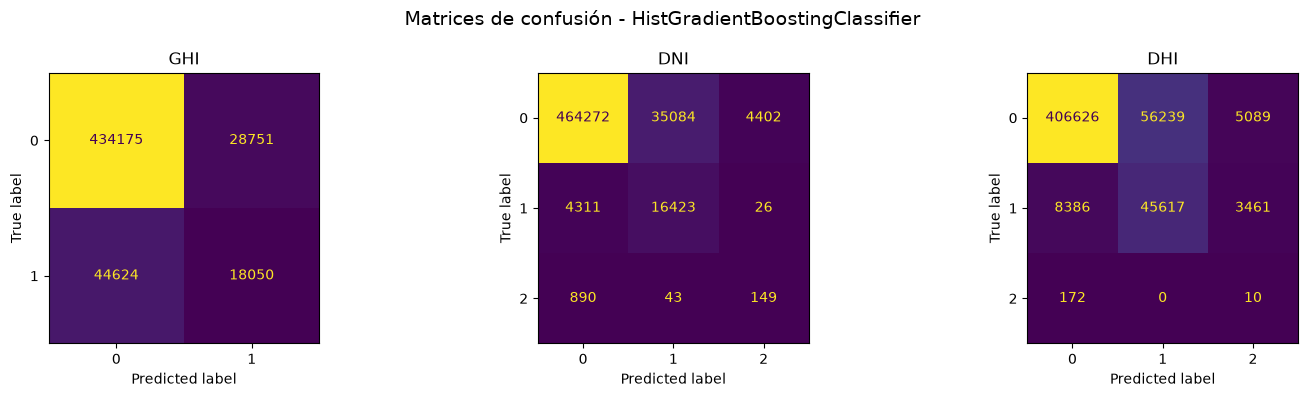

In [22]:
plot_confusion_matrices(
    test_df=test_df,
    predictions=hgb_predictions,
    targets=TARGETS,
    model_name="HistGradientBoostingClassifier"
)

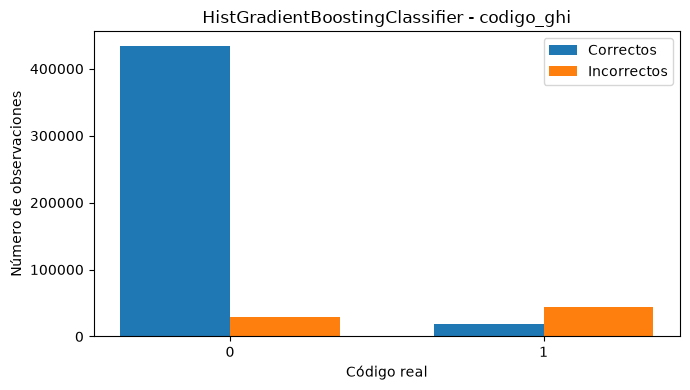

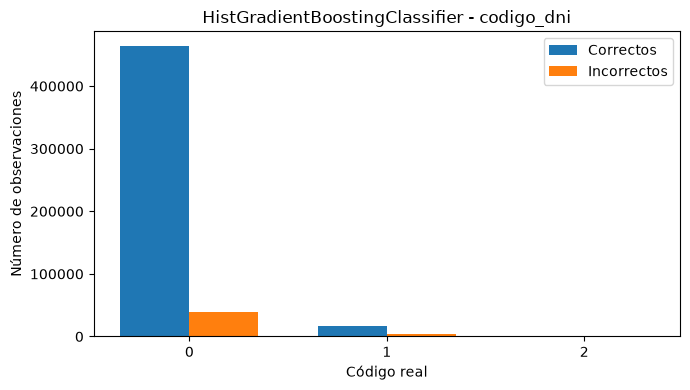

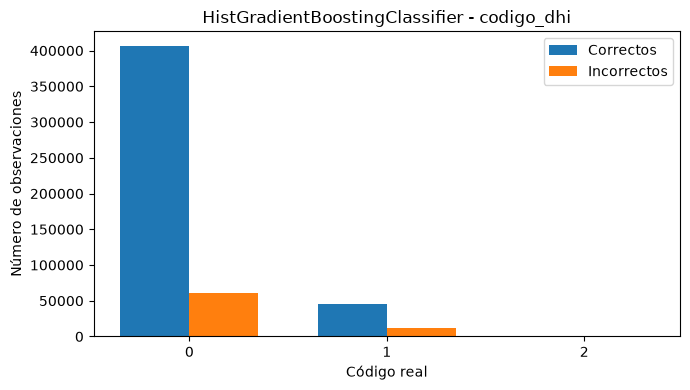

In [23]:
plot_correct_predictions_by_class(
    test_df=test_df,
    predictions=hgb_predictions,
    targets=TARGETS,
    model_name="HistGradientBoostingClassifier"
)

In [49]:
dummy_results["n_features"] = 0
hgb_results["n_features"] = len(FEATURES)

all_model_results = pd.concat(
    [
        dummy_results,
        hgb_results
    ],
    ignore_index=True
)

all_model_results

,f1_macro,balanced_accuracy,f1_weighted,model,target,n_features
0,0.468299,0.500000,0.824916,DummyClassifier,codigo_ghi,0
1,0.326260,0.333333,0.938106,DummyClassifier,codigo_dni,0
2,0.313993,0.333333,0.838667,DummyClassifier,codigo_dhi,0
3,0.625920,0.612946,0.851454,HistGradientBoostingClassifier,codigo_ghi,22
4,0.486994,0.616805,0.932485,HistGradientBoostingClassifier,codigo_dni,22
5,0.498600,0.572575,0.882477,HistGradientBoostingClassifier,codigo_dhi,22


In [25]:
model_comparison = create_model_comparison_table(
    all_model_results
)

model_comparison

,model,n_features,codigo_ghi,codigo_dni,codigo_dhi
0,DummyClassifier,22,0.468299,0.326260,0.313993
1,HistGradientBoostingClassifier,22,0.625920,0.486994,0.498600


## Persistencia de los resultados de modelado

Una vez definido y validado el procedimiento de evaluación, los resultados se almacenan también en las bases de datos desarrolladas previamente en el proyecto. PostgreSQL y MongoDB desempeñan funciones complementarias: PostgreSQL conserva la información estructurada y global de los experimentos, mientras que MongoDB permite almacenar información más detallada sobre el comportamiento diario de los modelos.

### Registro global de experimentos en PostgreSQL

PostgreSQL se utiliza como repositorio estructurado de los experimentos de Machine Learning. Para cada combinación modelo-target se registra la versión del dataset utilizada, los años de entrenamiento y prueba, el número y listado de variables predictoras y los hiperparámetros del algoritmo.

Las métricas globales de evaluación —Macro F1, Balanced Accuracy y Weighted F1— se almacenan de forma relacionada con cada modelo. De esta manera es posible comparar posteriormente diferentes algoritmos y configuraciones mediante consultas SQL manteniendo la trazabilidad con la versión concreta del dataset empleada.

In [ ]:
# from src.database.postgresql_persistence import (
#     save_model_results_postgresql
# )

# dummy_model_ids = save_model_results_postgresql(
#     results_df=dummy_results,
#     model_name="DummyClassifier",
#     dataset_version="processed_dataset_solar_v3",
#     features=[],
#     hyperparameters={
#         "strategy": "most_frequent"
#     },
#     train_year=2024,
#     test_year=2023
# )

# dummy_model_ids_by_target = dict(
#     zip(
#         dummy_results["target"],
#         dummy_model_ids
#     )
# )

# dummy_model_ids_by_target

DummyClassifier guardado correctamente para 3 targets.


{'codigo_ghi': 10, 'codigo_dni': 11, 'codigo_dhi': 12}

In [26]:
# from src.database.postgresql_persistence import (
#     save_model_results_postgresql
# )

# hgb_model_ids = save_model_results_postgresql(
#     results_df=hgb_results,
#     model_name="HistGradientBoostingClassifier",
#     dataset_version="processed_dataset_solar_v3",
#     features=FEATURES,
#     hyperparameters=hgb_models["codigo_ghi"].get_params(),
#     train_year=2024,
#     test_year=2023
# )

In [ ]:
dummy_model_ids_by_target = {
    "codigo_ghi": 10,
    "codigo_dni": 11,
    "codigo_dhi": 12
}

model_ids_by_target = {
    "codigo_ghi": 1,
    "codigo_dni": 2,
    "codigo_dhi": 3
}

### Registro del comportamiento diario en MongoDB

MongoDB complementa la información global almacenada en PostgreSQL mediante el registro del comportamiento de los modelos a nivel diario. Los resultados se incorporan al bloque `resultados_modelos` de los documentos ya existentes en la colección `daily_summaries`, sin generar nuevos documentos diarios.

Para cada modelo y variable objetivo se almacenan las métricas obtenidas en cada día, la distribución de códigos reales y predichos y la matriz de confusión correspondiente. Cada ejecución mantiene además el identificador del modelo registrado en PostgreSQL, permitiendo relacionar ambas fuentes de información.

La actualización se realiza de forma idempotente, por lo que una nueva ejecución del mismo modelo actualiza los resultados existentes en lugar de generar duplicados.

In [45]:
from src.mongodb.mongodb_persistence import save_model_results_mongodb
from src.mongodb.connection import get_mongodb_database

In [ ]:
hgb_mongo_results = save_model_results_mongodb(
    test_df=test_df,
    predictions=hgb_predictions,
    model_name="HistGradientBoostingClassifier",
    model_ids_by_target=model_ids_by_target,
    dataset_version="v3",
    features=FEATURES,
    targets=TARGETS,
    train_year=2024,
    test_year=2023
)

c:\Users\zacar\Desktop\Master IEBS DS & Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS & Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS & Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\zacar\Desktop\Master IEBS DS & Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was

Días procesados correctamente: 365
Días con error: 0


c:\Users\zacar\Desktop\Master IEBS DS & Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS & Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS & Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [46]:
dummy_mongo_results = save_model_results_mongodb(
    test_df=test_df,
    predictions=dummy_predictions,
    model_name="DummyClassifier",
    model_ids_by_target=dummy_model_ids_by_target,
    dataset_version="v3",
    features=[],
    targets=TARGETS,
    train_year=2024,
    test_year=2023
)

c:\Users\zacar\Desktop\Master IEBS DS & Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS & Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS & Big Data\TFM_IEBS\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\zacar\Desktop\Master IEBS DS & Big Data\TFM_IEBS\.venv\Lib\site-pac

Días procesados correctamente: 365
Días con error: 0


### Validación de la persistencia en MongoDB

Tras completar la carga masiva se comprueba que todos los días del conjunto de prueba disponen de resultados y que no se han producido errores durante el proceso.

Cada documento diario debe contener exactamente seis ejecuciones, correspondientes a las tres variables objetivo de cada uno de los dos modelos evaluados: `DummyClassifier` e `HistGradientBoostingClassifier`.

Esta validación permite comprobar tanto la cobertura completa del periodo de evaluación como la correcta integración de ambos modelos y la ausencia de duplicados en los documentos diarios.

In [ ]:
db, client = get_mongodb_database()
collection = db["daily_summaries"]

date_filter = {
    "$gte": datetime(2023, 1, 1),
    "$lt": datetime(2024, 1, 1)
}

n_days_with_results = collection.count_documents({
    "fecha": date_filter,
    "dataset.version": "v3",
    "resultados_modelos.disponible": True
})

invalid_docs = collection.count_documents({
    "fecha": date_filter,
    "dataset.version": "v3",
    "$expr": {
        "$ne": [
            {"$size": "$resultados_modelos.ejecuciones"},
            6
        ]
    }
})

print("Días 2023 con resultados:", n_days_with_results)

print(
    "HistGradientBoosting - días correctos:",
    len(hgb_mongo_results["success"])
)
print(
    "HistGradientBoosting - días con error:",
    len(hgb_mongo_results["errors"])
)

print(
    "DummyClassifier - días correctos:",
    len(dummy_mongo_results["success"])
)
print(
    "DummyClassifier - días con error:",
    len(dummy_mongo_results["errors"])
)

print(
    "Documentos con número incorrecto de ejecuciones:",
    invalid_docs
)

client.close()

Días 2023 con resultados: 365
HistGradientBoosting - días correctos: 365
HistGradientBoosting - días con error: 0
DummyClassifier - días correctos: 365
DummyClassifier - días con error: 0
Documentos con número incorrecto de ejecuciones: 0


## Conclusiones

En este notebook se ha definido el procedimiento que servirá como base para toda la fase de modelado. La comparación interanual utiliza los datos de 2024 para entrenamiento y los de 2023 como conjunto de prueba independiente, priorizando la mayor representación de las clases minoritarias en el conjunto de entrenamiento.

La Macro F1 se ha establecido como métrica principal, complementada mediante Balanced Accuracy, Weighted F1 y el análisis de las matrices de confusión. El `DummyClassifier` ha permitido establecer el nivel mínimo de referencia, mientras que el `HistGradientBoostingClassifier` ha obtenido una mejora clara para los tres códigos de calidad, alcanzando valores de Macro F1 de 0,626 para GHI, 0,487 para DNI y 0,499 para DHI.

Finalmente, se ha estandarizado el procedimiento de evaluación mediante funciones reutilizables y se ha integrado el flujo de modelado con las dos bases de datos del proyecto. PostgreSQL almacena la configuración y resultados globales de los experimentos, mientras que MongoDB recoge su comportamiento diario. La persistencia en MongoDB se ha completado correctamente para los 365 días del conjunto de prueba, sin errores ni duplicados.

Esta estructura permitirá que los siguientes modelos puedan entrenarse, evaluarse y registrarse utilizando un procedimiento común, facilitando su comparación directa.